# Analisis Explainability pada Model Prediksi Kebutuhan Energi Listrik Menggunakan Skforecast dan LightGBM

Pada tugas ini dilakukan reproduksi terhadap tutorial Explainability yang terdapat pada dokumentasi resmi Skforecast:

https://skforecast.org/0.15.1/user_guides/explainability.html

Kemampuan menjelaskan peramalan (Forecast Explainability) adalah teknik yang digunakan untuk memahami dan menjelaskan bagaimana model peramalan menghasilkan suatu prediksi. Tujuannya adalah agar proses pengambilan keputusan model tidak hanya menghasilkan prediksi yang akurat, tetapi juga dapat dipahami oleh pengguna. Dalam Skforecast, explainability dapat dilakukan menggunakan Feature Importance untuk mengetahui fitur yang paling berpengaruh, SHAP Values untuk melihat kontribusi masing-masing fitur terhadap hasil prediksi, dan Partial Dependence Plot (PDP) untuk memahami hubungan antara suatu fitur dengan nilai prediksi yang dihasilkan model. Teknik-teknik ini membantu meningkatkan transparansi, kepercayaan, dan interpretasi terhadap model peramalan.

## instalasi Skforecast
Pada tahap ini dilakukan instalasi Skforecast versi 0.15.1 menggunakan perintah pip install. Output "Requirement already satisfied" menunjukkan bahwa Skforecast dan seluruh library pendukung yang dibutuhkan sudah terpasang dengan baik, sehingga lingkungan kerja siap digunakan untuk proses forecasting dan explainability.

In [ ]:
!pip install skforecast==0.15.1

## Import Libary
Pada tahap ini dilakukan import library yang diperlukan untuk proses analisis. Library yang digunakan meliputi Pandas untuk pengolahan data, Matplotlib untuk visualisasi, SHAP untuk explainability model, Scikit-learn untuk analisis feature importance dan partial dependence plot, LightGBM sebagai algoritma prediksi, serta Skforecast untuk membangun model forecasting deret waktu (time series).

In [ ]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Mengunduh Dataset
Pada tahap ini dilakukan pengambilan dataset vic_electricity menggunakan fungsi fetch_dataset(). Dataset yang digunakan berisi data permintaan listrik (Demand), suhu (Temperature), tanggal (Date), dan hari libur (Holiday) di Victoria, Australia dengan total 52.608 baris dan 4 kolom. Perintah data.head(3) digunakan untuk menampilkan tiga baris pertama dataset sebagai langkah awal eksplorasi data.

In [ ]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


## Agregasi Data
Pada tahap ini dilakukan agregasi data dari frekuensi setengah jam menjadi harian (daily frequency) menggunakan fungsi resample('D'). Nilai Demand dijumlahkan setiap hari, sedangkan Temperature dihitung rata-ratanya. Tujuannya adalah menyederhanakan data agar lebih mudah digunakan dalam proses analisis dan pemodelan forecasting.

In [ ]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


## Pembagian Dataset Menjadi Data Training dan Testing.
Pada tahap ini dilakukan pembagian dataset menjadi data training dan data testing. Data hingga tanggal 21 Desember 2014 digunakan sebagai data training untuk melatih model, sedangkan data mulai 22 Desember 2014 digunakan sebagai data testing untuk menguji kemampuan model dalam melakukan prediksi pada data yang belum pernah dilihat sebelumnya. Pembagian ini penting untuk mengevaluasi performa model secara objektif.

In [ ]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

## Pembuatan dan Pelatihan Model ForecasterRecursive
Pada tahap ini dibuat model ForecasterRecursive dengan algoritma LightGBM Regressor dan menggunakan 7 lag sebagai fitur prediksi. Model kemudian dilatih menggunakan data Demand sebagai target dan Temperature sebagai variabel eksternal (exogenous variable). Setelah proses pelatihan selesai, ditampilkan informasi model yang menunjukkan konfigurasi, parameter, serta status model yang telah berhasil dilatih dan siap digunakan untuk melakukan forecasting.

In [ ]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 regressor = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 15:37:34 
Last fit date: 2026-06-10 15:37:34 
Skforecast version: 0.15.1 
Python version: 3.12.13 
Forecaster id: None

## Analisis Feature Importance
Pada tahap ini dilakukan analisis Feature Importance untuk mengetahui fitur yang paling berpengaruh dalam proses prediksi. Hasil menunjukkan bahwa Temperature memiliki tingkat kepentingan tertinggi dengan nilai 570, sehingga menjadi faktor yang paling berpengaruh terhadap prediksi demand listrik. Selain itu, fitur lag_1 hingga lag_7 juga memberikan kontribusi yang signifikan, yang menunjukkan bahwa nilai demand pada periode-periode sebelumnya sangat memengaruhi prediksi demand pada periode berikutnya.

In [ ]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


## Membentuk Data Training Buat Model
Pada tahap ini dibuat matriks training (X_train dan y_train) yang digunakan oleh model untuk proses pembelajaran. Variabel X_train berisi fitur prediktor berupa lag_1 hingga lag_7 serta Temperature, sedangkan y_train berisi nilai target Demand yang akan diprediksi. Hasil ini menunjukkan bagaimana data time series diubah menjadi format supervised learning sehingga dapat diproses oleh algoritma machine learning.

In [ ]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


## Membuat SHAP Explainer
Pada tahap ini dibuat SHAP Explainer untuk menganalisis kontribusi masing-masing fitur terhadap hasil prediksi model. Fungsi TreeExplainer() digunakan karena model yang dipakai adalah LightGBM berbasis pohon keputusan (tree-based model). Selanjutnya, nilai SHAP (SHapley Additive Explanations) dihitung untuk setiap data pada X_train, sehingga dapat diketahui seberapa besar pengaruh setiap fitur, seperti Temperature dan lag, terhadap prediksi yang dihasilkan model.

In [ ]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

## Visualisasi SHAP Feature Importance
Pada tahap ini ditampilkan SHAP Summary Plot dalam bentuk diagram batang (bar plot) untuk menunjukkan tingkat pengaruh setiap fitur terhadap hasil prediksi model secara keseluruhan. Grafik menunjukkan bahwa lag_1 merupakan fitur yang paling berpengaruh, diikuti oleh Temperature dan lag_7. Semakin panjang batang pada grafik, semakin besar kontribusi fitur tersebut terhadap prediksi demand listrik. Hasil ini membantu memahami fitur mana yang paling penting dalam proses forecasting.

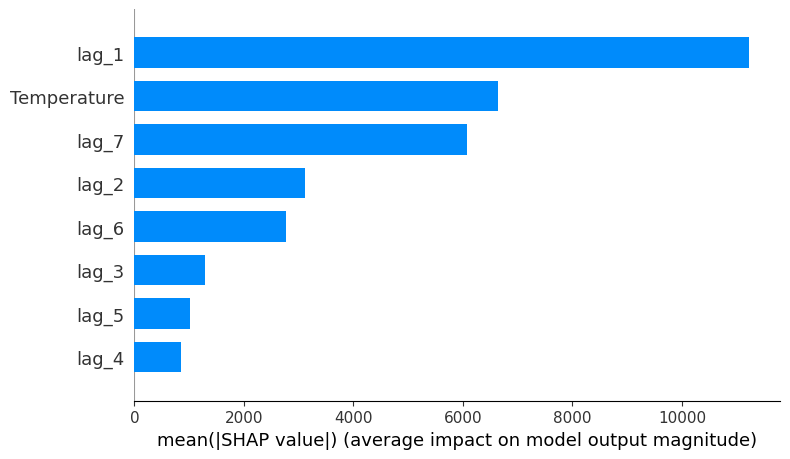

In [ ]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

## Visualisasi Distribusi dan Pengaruh Fitur dengan SHAP
Pada tahap ini ditampilkan SHAP Summary Plot (beeswarm plot) untuk melihat pengaruh setiap fitur terhadap hasil prediksi secara lebih detail. Setiap titik mewakili satu observasi data, sedangkan warna menunjukkan nilai fitur (biru = rendah, merah = tinggi). Grafik menunjukkan bahwa lag_1, Temperature, dan lag_7 merupakan fitur yang paling berpengaruh terhadap prediksi demand listrik. Nilai SHAP positif menunjukkan fitur meningkatkan hasil prediksi, sedangkan nilai SHAP negatif menunjukkan fitur menurunkan hasil prediksi. Visualisasi ini membantu memahami bagaimana setiap fitur berkontribusi terhadap keputusan model.

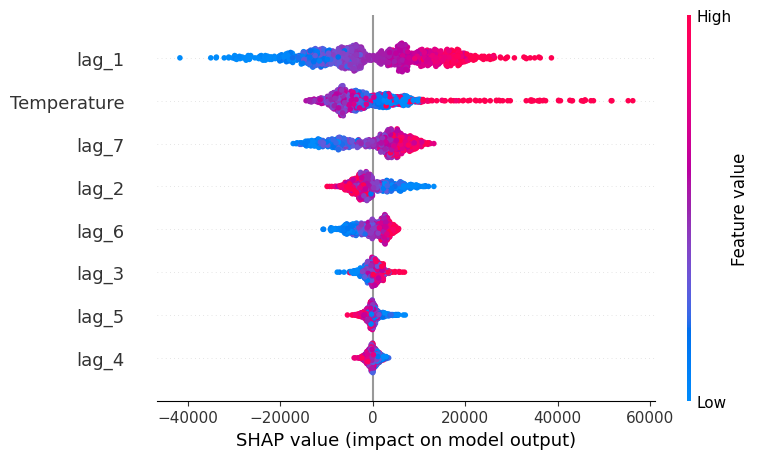

In [ ]:
shap.summary_plot(shap_values, X_train)

## SHAP Force Plot untuk Menjelaskan Kontribusi Fitur pada Prediksi Demand Listrik
Pada tahap ini ditampilkan **SHAP Force Plot** untuk observasi pertama pada data training. Visualisasi ini menunjukkan bagaimana setiap fitur berkontribusi terhadap hasil prediksi model. Fitur yang berwarna **merah** memberikan pengaruh positif (meningkatkan nilai prediksi), sedangkan fitur yang berwarna **biru** memberikan pengaruh negatif (menurunkan nilai prediksi). Dari hasil visualisasi terlihat bahwa **Temperature**, **lag_2**, **lag_6**, dan **lag_7** memberikan kontribusi yang meningkatkan hasil prediksi, sementara **lag_1** dan **lag_3** memberikan kontribusi yang menurunkan nilai prediksi. Visualisasi ini membantu memahami alasan model menghasilkan nilai prediksi pada suatu observasi tertentu.

In [32]:
# Force plot for the first observation
# ==============================================================================
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

## SHAP Force Plot untuk 200 Observasi pada Data Training

Pada tahap ini ditampilkan **SHAP Force Plot** untuk 200 observasi pertama pada data training. Visualisasi ini digunakan untuk melihat kontribusi setiap fitur terhadap hasil prediksi model secara kolektif. Warna **merah** menunjukkan fitur yang meningkatkan nilai prediksi, sedangkan warna **biru** menunjukkan fitur yang menurunkan nilai prediksi. Dari visualisasi terlihat bahwa pengaruh fitur seperti **Temperature** dan beberapa **lag** berbeda-beda pada setiap observasi, sehingga dapat diketahui bagaimana model mengambil keputusan pada berbagai kondisi data. Analisis ini membantu memahami pola kontribusi fitur secara keseluruhan dan meningkatkan transparansi model forecasting.

In [37]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

## SHAP Dependence Plot untuk Variabel Temperature

Plot ini menunjukkan hubungan antara nilai **Temperature** dengan kontribusinya terhadap hasil prediksi berdasarkan nilai SHAP. Terlihat bahwa perubahan suhu memberikan pengaruh yang berbeda terhadap prediksi demand listrik. Pada suhu yang lebih tinggi, nilai SHAP cenderung meningkat, yang menunjukkan bahwa temperatur memiliki kontribusi yang semakin besar dalam meningkatkan hasil prediksi model. Visualisasi ini juga memperlihatkan interaksi antara **Temperature** dan **lag_1** yang ditunjukkan melalui gradasi warna pada titik-titik data.

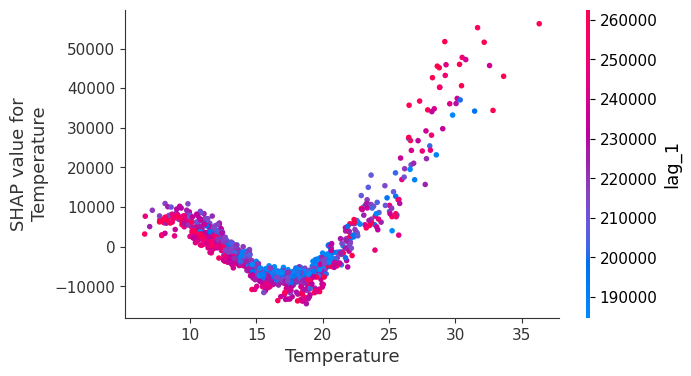

In [ ]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

## Prediksi Demand Listrik untuk 10 Hari ke Depan

Pada tahap ini dilakukan **prediksi demand listrik** menggunakan model `ForecasterRecursive` yang telah dilatih. Model menghasilkan prediksi untuk **10 hari pertama pada data testing** berdasarkan nilai **Temperature** sebagai variabel eksternal. Hasil prediksi menunjukkan estimasi kebutuhan listrik per hari, yang nantinya dapat digunakan untuk analisis perencanaan energi atau evaluasi performa model forecasting.

In [ ]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


## Matriks Input untuk Prediksi 10 Hari ke Depan

Pada tahap ini dibuat **matriks input (X_predict)** untuk melakukan prediksi **10 hari ke depan** menggunakan model `ForecasterRecursive`. Matriks ini berisi fitur **lag_1 hingga lag_7** dari nilai demand sebelumnya serta nilai **Temperature** sebagai variabel eksternal. Matriks ini digunakan oleh metode `predict()` untuk menghasilkan prediksi demand listrik per hari berdasarkan data terbaru dan pola historis yang telah dipelajari oleh model.

In [ ]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


## SHAP Force Plot untuk Prediksi Tertentu

Pada tahap ini ditampilkan **SHAP Force Plot** untuk menjelaskan hasil prediksi pada tanggal **22 Desember 2014**. Visualisasi ini menunjukkan kontribusi masing-masing fitur terhadap nilai prediksi yang dihasilkan model. Fitur yang berwarna **merah** memberikan pengaruh positif sehingga meningkatkan nilai prediksi, sedangkan fitur yang berwarna **biru** memberikan pengaruh negatif yang menurunkan nilai prediksi. Dari hasil visualisasi terlihat bahwa **Temperature**, **lag_2**, **lag_6**, dan **lag_7** memberikan kontribusi positif yang cukup besar, sementara **lag_1** dan **lag_3** memberikan kontribusi negatif. Analisis ini membantu memahami faktor-faktor yang memengaruhi hasil prediksi pada tanggal yang dipilih.

In [38]:
# Force plot for a specific prediction
# ==============================================================================
shap.initjs()
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

## Analisis Feature Importance Menggunakan Permutation Importance

Pada tahap ini dilakukan analisis **Permutation Importance** untuk mengukur tingkat pengaruh setiap fitur terhadap kinerja model. Metode ini bekerja dengan mengacak nilai suatu fitur dan mengamati perubahan performa model. Hasil menunjukkan bahwa **lag_1** merupakan fitur yang paling penting dengan nilai rata-rata importance sebesar **0,617276**, diikuti oleh **Temperature** sebesar **0,411240** dan **lag_7** sebesar **0,196190**. Temuan ini menunjukkan bahwa nilai demand pada periode sebelumnya dan suhu memiliki peran yang paling besar dalam menentukan hasil prediksi demand listrik yang dihasilkan model.

In [ ]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.regressor,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


## Partial Dependence Plot untuk Temperature dan Lag_1

Plot ini menunjukkan **Partial Dependence** untuk fitur **Temperature** dan **lag_1**, yang menggambarkan hubungan antara nilai fitur dengan prediksi model sambil memperhitungkan efek rata-rata dari fitur lainnya. Dari grafik terlihat bahwa:

- Untuk **Temperature**, prediksi demand cenderung meningkat ketika suhu lebih tinggi.
- Untuk **lag_1**, nilai demand sebelumnya berpengaruh signifikan terhadap prediksi demand hari berikutnya.

Partial Dependence Plot membantu memahami pengaruh individual fitur terhadap prediksi model dan interaksinya dengan variabel lain.

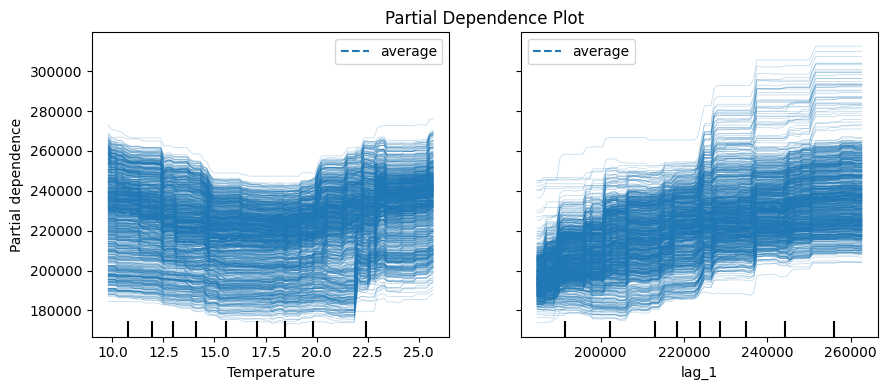

In [ ]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();

## Soal dan Jawaban serta penjelasannya

## 1. Analisa Predikisi Tentang Apa?

Analisis ini bertujuan untuk memprediksi **permintaan energi listrik (Demand)** di Victoria, Australia berdasarkan data historis konsumsi listrik dan suhu lingkungan. Prediksi dilakukan menggunakan model forecasting berbasis machine learning dengan memanfaatkan data demand sebelumnya (lag) dan variabel temperatur sebagai faktor pendukung.

### Detail Prediksi

Prediksi yang dilakukan dalam analisis ini adalah **permintaan energi listrik harian (Demand)** di Victoria, Australia. Model menggunakan data historis konsumsi listrik selama beberapa hari sebelumnya (**lag_1 hingga lag_7**) serta data **Temperature** sebagai variabel eksternal untuk memperkirakan kebutuhan listrik pada periode berikutnya.

Model yang digunakan adalah **ForecasterRecursive** dengan algoritma **LightGBM Regressor**. Pendekatan recursive forecasting memungkinkan hasil prediksi sebelumnya digunakan kembali sebagai input untuk menghasilkan prediksi pada periode selanjutnya. Pada analisis ini dilakukan prediksi untuk **10 hari ke depan** menggunakan data testing yang telah dipisahkan dari data training.

### Teknik Explainability yang Digunakan

Untuk memahami bagaimana model menghasilkan prediksi, digunakan beberapa teknik explainability sebagai berikut:

1. Feature Importance

Feature Importance digunakan untuk mengukur tingkat pengaruh setiap fitur terhadap hasil prediksi model. Hasil analisis menunjukkan bahwa **Temperature**, **lag_1**, dan **lag_7** merupakan fitur yang memiliki pengaruh terbesar terhadap prediksi demand listrik.

2. Permutation Importance

Permutation Importance mengukur pentingnya fitur dengan cara mengacak nilai suatu fitur dan melihat perubahan performa model. Dari hasil analisis diperoleh bahwa **lag_1** merupakan fitur yang paling berpengaruh, diikuti oleh **Temperature** dan **lag_7**.

3. SHAP (SHapley Additive Explanations)

SHAP digunakan untuk menjelaskan kontribusi masing-masing fitur terhadap hasil prediksi. Melalui SHAP Summary Plot dan Force Plot dapat diketahui apakah suatu fitur meningkatkan atau menurunkan nilai prediksi serta seberapa besar pengaruhnya terhadap keputusan model.

4. SHAP Dependence Plot

SHAP Dependence Plot digunakan untuk menganalisis hubungan antara nilai suatu fitur dengan kontribusinya terhadap prediksi. Pada analisis ini digunakan fitur **Temperature**, sehingga dapat diketahui bagaimana perubahan suhu memengaruhi hasil prediksi demand listrik.

5. Partial Dependence Plot (PDP)

Partial Dependence Plot digunakan untuk melihat pengaruh rata-rata suatu fitur terhadap hasil prediksi model. Pada analisis ini digunakan fitur **Temperature** dan **lag_1** untuk memahami hubungan antara kedua fitur tersebut dengan nilai demand yang diprediksi.

## 2. Bentuk Data Training Input dan Output ( apa saja inpunya dan apa outpunya)

Pada analisis ini, data time series diubah terlebih dahulu menjadi format **supervised learning** agar dapat digunakan oleh algoritma machine learning. Proses ini dilakukan dengan memanfaatkan nilai demand pada beberapa hari sebelumnya (*lag*) sebagai fitur input dan nilai demand pada hari berikutnya sebagai target output.

### Input (X_train)

Data training **input** terdiri dari:

1. **lag_1 hingga lag_7**, yaitu nilai demand listrik pada 7 hari sebelumnya.
2. **Temperature**, yaitu suhu harian yang digunakan sebagai variabel eksternal (*exogenous variable*).

Contoh sebagian data input (X_train):

| lag_1 | lag_2 | lag_3 | lag_4 | lag_5 | lag_6 | lag_7 | Temperature |
|--------:|--------:|--------:|--------:|--------:|--------:|--------:|------------:|
| 205338.71 | 211066.42 | 213792.38 | 258955.33 | 275490.99 | 227778.26 | 82531.75 | 24.09 |
| 200693.27 | 205338.71 | 211066.43 | 213792.38 | 258955.33 | 275490.99 | 227778.26 | 20.22 |
| 200061.61 | 200693.27 | 205338.63 | 211066.43 | 213792.38 | 258955.33 | 275490.99 | 19.16 |

### Output (y_train)

Data training **output** berupa nilai target yang akan diprediksi oleh model, yaitu:

- **Demand** (permintaan energi listrik pada hari berikutnya).

Contoh sebagian data output (y_train):

| Demand |
|---------:|
| 200693.27 |
| 200061.61 |
| 216201.84 |

### Ilustrasi Transformasi Data Training

Sebelum digunakan untuk melatih model, data historis demand diubah menjadi fitur lag. Sebagai contoh:

| Hari | Demand |
|------|---------:|
| H-7 | 82531.75 |
| H-6 | 227778.26 |
| H-5 | 275490.99 |
| H-4 | 258955.33 |
| H-3 | 213792.38 |
| H-2 | 211066.43 |
| H-1 | 205338.71 |
| H | 200693.27 |

Maka akan dibentuk satu baris data training seperti berikut:

| lag_1 | lag_2 | lag_3 | lag_4 | lag_5 | lag_6 | lag_7 | Temperature | Target (Demand) |
|--------:|--------:|--------:|--------:|--------:|--------:|--------:|------------:|---------------:|
| 205338.71 | 211066.43 | 213792.38 | 258955.33 | 275490.99 | 227778.26 | 82531.75 | 24.09 | 200693.27 |

Pada ilustrasi tersebut, **lag_1 hingga lag_7** digunakan sebagai fitur input, sedangkan **Demand pada hari H** digunakan sebagai target output. Dengan cara ini, model dapat mempelajari hubungan antara pola historis konsumsi listrik dan suhu terhadap kebutuhan listrik pada periode berikutnya.

## 3. Apa itu Lag?

Lag adalah nilai historis dari suatu variabel yang digunakan sebagai fitur input untuk memprediksi nilai pada periode berikutnya. Dalam analisis time series, lag berfungsi sebagai representasi informasi masa lalu yang dapat membantu model memahami pola data.

Pada kasus prediksi demand listrik, lag yang digunakan adalah:

- **lag_1** = nilai demand 1 hari sebelumnya
- **lag_2** = nilai demand 2 hari sebelumnya
- **lag_3** = nilai demand 3 hari sebelumnya
- ...
- **lag_7** = nilai demand 7 hari sebelumnya

Dengan kata lain, model tidak hanya melihat kondisi saat ini, tetapi juga memanfaatkan informasi dari beberapa hari sebelumnya untuk menghasilkan prediksi yang lebih akurat.

### Mengapa Lag Penting?

Data time series memiliki karakteristik bahwa nilai pada suatu waktu sering dipengaruhi oleh nilai pada waktu sebelumnya. Oleh karena itu, penggunaan lag sangat penting karena:

1. **Menangkap pola historis**
   
   Lag memungkinkan model mempelajari pola konsumsi listrik dari hari-hari sebelumnya.

2. **Mengenali tren dan musiman**
   
   Jika terdapat pola mingguan atau kecenderungan tertentu dalam penggunaan listrik, model dapat mengenalinya melalui nilai lag.

3. **Meningkatkan akurasi prediksi**
   
   Informasi masa lalu sering kali memiliki hubungan yang kuat dengan nilai yang akan diprediksi.

4. **Mengubah data time series menjadi supervised learning**
   
   Algoritma machine learning seperti LightGBM memerlukan data dalam bentuk input dan output. Lag digunakan untuk mengubah data deret waktu menjadi format yang dapat diproses oleh model.

### Ilustrasi Pembentukan Lag

Misalkan terdapat data demand listrik sebagai berikut:

| Hari | Demand |
|------|---------:|
| Senin | 180000 |
| Selasa | 190000 |
| Rabu | 200000 |
| Kamis | 210000 |
| Jumat | 220000 |
| Sabtu | 230000 |
| Minggu | 240000 |
| Senin berikutnya | 250000 |

Maka satu baris data training akan dibentuk menjadi:

| lag_1 | lag_2 | lag_3 | lag_4 | lag_5 | lag_6 | lag_7 | Target |
|--------:|--------:|--------:|--------:|--------:|--------:|--------:|--------:|
| 240000 | 230000 | 220000 | 210000 | 200000 | 190000 | 180000 | 250000 |

Pada contoh tersebut:

- lag_1 berasal dari demand hari Minggu
- lag_2 berasal dari demand hari Sabtu
- lag_3 berasal dari demand hari Jumat
- dan seterusnya
- Target merupakan demand pada hari Senin berikutnya yang akan diprediksi model

### Mengapa Dipilih Lag = 7?

Pada tutorial ini digunakan **lag = 7**, yang berarti model memanfaatkan data demand dari tujuh hari sebelumnya.

Pemilihan lag 7 dilakukan karena:

1. **Mewakili satu siklus mingguan**
   
   Konsumsi listrik umumnya memiliki pola yang berulang setiap minggu, sehingga data tujuh hari sebelumnya dapat memberikan informasi yang relevan.

2. **Menangkap perbedaan hari kerja dan akhir pekan**
   
   Kebutuhan listrik pada hari kerja sering berbeda dengan akhir pekan. Dengan menggunakan lag selama satu minggu penuh, model dapat mengenali pola tersebut.

3. **Mengurangi kompleksitas model**
   
   Menggunakan terlalu banyak lag dapat meningkatkan jumlah fitur dan membuat model lebih kompleks. Lag 7 dipilih sebagai jumlah yang cukup untuk menangkap pola penting tanpa menambah kompleksitas secara berlebihan.

4. **Sesuai dengan tutorial Skforecast**
   
   Tutorial Explainability pada Skforecast menggunakan konfigurasi lag 7 sebagai fitur utama dalam proses forecasting dan interpretasi model.

## 4. Penjelasan Proses Analysis Yang Dilakukan Dari Kasus Diatas

Analisis pada kasus ini bertujuan untuk memprediksi **permintaan energi listrik (Demand)** menggunakan data historis konsumsi listrik dan temperatur. Selain menghasilkan prediksi, analisis juga dilakukan untuk memahami faktor-faktor yang memengaruhi hasil prediksi melalui teknik explainability.

### Tahapan Analisis

1. **Persiapan dan Pengambilan Data**  
   Dataset **vic_electricity** diambil menggunakan fungsi `fetch_dataset()` dari Skforecast. Dataset ini berisi informasi mengenai:
   - Demand (permintaan listrik)
   - Temperature (suhu)
   - Holiday (hari libur)
   - Date (tanggal)

2. **Transformasi Data**  
   Data asli memiliki frekuensi setengah jam (*half-hourly*). Agar lebih mudah dianalisis, data diubah menjadi **data harian** (*daily frequency*) menggunakan proses resampling:
   - Demand dijumlahkan setiap hari.
   - Temperature dihitung rata-ratanya setiap hari.

3. **Pembagian Data Training dan Testing**  
   Data dibagi menjadi:
   - **Training** → untuk melatih model.  
   - **Testing** → untuk menguji prediksi model.  

4. **Pembentukan Fitur Lag**  
   Fitur **lag_1 hingga lag_7** dibuat untuk menangkap pola historis.  
   Contoh: lag_1 = demand 1 hari sebelumnya, lag_2 = 2 hari sebelumnya, dan seterusnya.

5. **Pembuatan dan Pelatihan Model**  
   Model dibuat menggunakan:
   - **ForecasterRecursive**  
   - **LightGBM Regressor**  
   Model dilatih menggunakan input lag dan Temperature sebagai variabel eksternal.

6. **Analisis Feature Importance**  
   Dilakukan untuk mengetahui fitur yang paling berpengaruh terhadap prediksi. Hasil menunjukkan **Temperature**, **lag_1**, dan **lag_7** sebagai fitur utama.

7. **Analisis SHAP (SHapley Additive Explanations)**  
   Menjelaskan kontribusi masing-masing fitur terhadap prediksi. Visualisasi yang digunakan antara lain: Summary Plot, Force Plot, dan Dependence Plot.

8. **Prediksi Demand Listrik**  
   Model digunakan untuk memprediksi demand selama **10 hari ke depan**, menggunakan lag dan Temperature.

9. **Analisis Permutation Importance**  
   Mengukur pentingnya fitur dengan mengacak nilai fitur dan melihat penurunan performa model. Fitur terpenting: **lag_1**, **Temperature**, **lag_7**.

10. **Analisis Partial Dependence Plot (PDP)**  
    Menunjukkan pengaruh rata-rata fitur terhadap prediksi model. Fitur yang dianalisis: **Temperature** dan **lag_1**.

11. **Interpretasi Hasil dan Kesimpulan**  
    Teknik explainability seperti Feature Importance, SHAP, Permutation Importance, dan PDP membantu memahami faktor-faktor yang memengaruhi prediksi, sehingga model menjadi lebih transparan dan keputusan prediksi lebih dapat dipertanggungjawabkan.


### Diagram Alur Analisis

```text
Mulai
  │
  ▼
Mengambil Dataset
(vic_electricity)
  │
  ▼
Eksplorasi Data
(data.head(), info)
  │
  ▼
Transformasi Data
(Half-hourly → Daily)
  │
  ▼
Membagi Data
Training dan Testing
  │
  ▼
Membentuk Fitur Lag
(lag_1 sampai lag_7)
  │
  ▼
Membangun Model
ForecasterRecursive + LightGBM
  │
  ▼
Melatih Model
(Fit Model)
  │
  ▼
Analisis Feature Importance
  │
  ▼
Analisis SHAP
(Summary Plot, Force Plot,
Dependence Plot)
  │
  ▼
Melakukan Prediksi
Demand Listrik
(10 Hari Ke Depan)
  │
  ▼
Analisis Permutation Importance
  │
  ▼
Analisis Partial Dependence Plot
(PDP)
  │
  ▼
Interpretasi Hasil
dan Explainability
  │
  ▼
Kesimpulan
```

### Penjelasan Diagram Alur

Diagram alur di atas menunjukkan tahapan analisis mulai dari pengambilan dataset hingga interpretasi hasil. Proses dimulai dengan pengambilan dan transformasi data, dilanjutkan dengan pembentukan fitur lag serta pelatihan model forecasting menggunakan LightGBM. Setelah model berhasil dilatih, dilakukan berbagai analisis explainability seperti Feature Importance, SHAP, Permutation Importance, dan Partial Dependence Plot untuk memahami faktor-faktor yang memengaruhi hasil prediksi. Tahap akhir adalah melakukan interpretasi hasil dan menyusun kesimpulan berdasarkan analisis yang telah dilakukan.

## Kesimpulan

Berdasarkan hasil analisis, model **ForecasterRecursive** dengan algoritma **LightGBM** berhasil digunakan untuk memprediksi permintaan energi listrik harian (*Demand*) menggunakan data historis konsumsi listrik (**lag_1 hingga lag_7**) dan variabel suhu (**Temperature**). Hasil analisis menunjukkan bahwa fitur **Temperature**, **lag_1**, dan **lag_7** merupakan faktor yang paling berpengaruh terhadap prediksi. Selain menghasilkan prediksi untuk 10 hari ke depan, penelitian ini juga menerapkan teknik explainability seperti **Feature Importance**, **Permutation Importance**, **SHAP**, dan **Partial Dependence Plot (PDP)** untuk memahami kontribusi masing-masing fitur terhadap hasil prediksi. Dengan demikian, model tidak hanya mampu memberikan prediksi yang akurat, tetapi juga menghasilkan prediksi yang lebih transparan, mudah dipahami, dan dapat digunakan sebagai dasar pengambilan keputusan dalam perencanaan kebutuhan energi listrik.